# Comprehensive Workload Clustering Analysis

This notebook performs workload clustering using multiple approaches:
1. **Vector-based features**: Extracted SQL structural features (joins, aggregates, predicates, etc.)
2. **Word embeddings**: Multiple embedding types including:
   - FastText (subword-aware embeddings)
   - Word2Vec (context-based word embeddings)
   - TF-IDF (term frequency-inverse document frequency)
   - Sentence Transformers (BERT-based contextual embeddings)

The pipeline includes dimensionality reduction (UMAP & PCA), clustering (HDBSCAN), evaluation metrics, and visualization.

## 1. Import Required Libraries

### Installation Requirements

Run this cell if you need to install required packages:

```bash
pip install sqlglot umap-learn hdbscan pandas numpy matplotlib seaborn scikit-learn scipy gensim sentence-transformers
```

In [4]:
import os
import shutil
import sqlglot
import umap
import hdbscan
import pandas as pd
import numpy as np
import logging
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from sklearn.feature_extraction.text import TfidfVectorizer
import glob

# Embedding models
from gensim.models import FastText, Word2Vec
from sentence_transformers import SentenceTransformer

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
warnings.filterwarnings('ignore')

## 2. Feature Extraction Functions

These functions extract comprehensive SQL features including:
- Query structure (SELECT, JOIN, WHERE, GROUP BY, ORDER BY)
- Predicate types (AND, OR, LIKE, IN, BETWEEN)
- Complexity indicators (CASE, CAST, subqueries, CTEs)
- Join types (INNER, LEFT, RIGHT, FULL, CROSS)

In [5]:
def extract_sql_features(sql_query):
    """Extract comprehensive structural features from a SQL query."""
    features = {}
    try:
        statements = [s for s in sql_query.split(';') if s.strip()]
        counts = {
            'selects': 0, 'joins': 0, 'wheres': 0, 'groups': 0, 'orders': 0, 
            'limits': 0, 'subqueries': 0, 'aggregates': 0, 'ctes': 0, 
            'distinct_tables': set(), 
            'pred_and': 0, 'pred_or': 0, 'pred_like': 0, 'pred_in': 0, 
            'pred_between': 0, 'pred_exists': 0, 'pred_comparison': 0,
            'complexity_case': 0, 'complexity_cast': 0, 'complexity_alias': 0, 'complexity_window': 0,
            'join_inner': 0, 'join_left': 0, 'join_right': 0, 'join_full': 0, 'join_cross': 0
        }
        
        for stmt in statements:
            try:
                parsed = sqlglot.parse_one(stmt, read='postgres')
                counts['selects'] += len(list(parsed.find_all(sqlglot.exp.Select)))
                joins = list(parsed.find_all(sqlglot.exp.Join))
                counts['joins'] += len(joins)
                counts['wheres'] += len(list(parsed.find_all(sqlglot.exp.Where)))
                counts['groups'] += len(list(parsed.find_all(sqlglot.exp.Group)))
                counts['orders'] += 1 if list(parsed.find_all(sqlglot.exp.Order)) else 0
                counts['limits'] += 1 if list(parsed.find_all(sqlglot.exp.Limit)) else 0
                counts['subqueries'] += len(list(parsed.find_all(sqlglot.exp.Subquery)))
                counts['ctes'] += len(list(parsed.find_all(sqlglot.exp.CTE)))
                
                # Count aggregate functions
                for agg in (sqlglot.exp.Sum, sqlglot.exp.Avg, sqlglot.exp.Count, sqlglot.exp.Max, sqlglot.exp.Min):
                    counts['aggregates'] += len(list(parsed.find_all(agg)))
                
                counts['complexity_window'] += len(list(parsed.find_all(sqlglot.exp.Window)))
                
                # Count distinct tables
                for table in parsed.find_all(sqlglot.exp.Table):
                    counts['distinct_tables'].add(table.name.lower())
                
                # Count predicates
                counts['pred_and'] += len(list(parsed.find_all(sqlglot.exp.And)))
                counts['pred_or'] += len(list(parsed.find_all(sqlglot.exp.Or)))
                counts['pred_like'] += len(list(parsed.find_all(sqlglot.exp.Like)))
                counts['pred_in'] += len(list(parsed.find_all(sqlglot.exp.In)))
                counts['pred_between'] += len(list(parsed.find_all(sqlglot.exp.Between)))
                counts['pred_exists'] += len(list(parsed.find_all(sqlglot.exp.Exists)))
                
                for comp in (sqlglot.exp.GT, sqlglot.exp.LT, sqlglot.exp.GTE, sqlglot.exp.LTE, sqlglot.exp.NEQ):
                    counts['pred_comparison'] += len(list(parsed.find_all(comp)))
                
                # Count complexity indicators
                counts['complexity_case'] += len(list(parsed.find_all(sqlglot.exp.Case)))
                counts['complexity_cast'] += len(list(parsed.find_all(sqlglot.exp.Cast))) + len(list(parsed.find_all(sqlglot.exp.TryCast)))
                counts['complexity_alias'] += len(list(parsed.find_all(sqlglot.exp.Alias)))
                
                # Count join types
                for j in joins:
                    kind = j.kind
                    if kind == 'CROSS': counts['join_cross'] += 1
                    elif kind == 'FULL': counts['join_full'] += 1
                    elif kind == 'LEFT': counts['join_left'] += 1
                    elif kind == 'RIGHT': counts['join_right'] += 1
                    else: counts['join_inner'] += 1
            except: 
                continue
        
        features = {k: (len(v) if isinstance(v, set) else v) for k, v in counts.items()}
    except: 
        return None
    
    return features

In [6]:
def get_vector_workload_features(file_path):
    """Extract workload-level statistical features from all queries in a file."""
    with open(file_path, 'r') as f:
        queries = f.readlines()
    
    all_feats = [extract_sql_features(q) for q in queries if q.strip()]
    all_feats = [f for f in all_feats if f]
    
    if not all_feats: 
        return None
    
    df = pd.DataFrame(all_feats)
    stats = {}
    
    # Compute mean, median, std, and percentiles for each feature
    for col in df.columns:
        stats[f"{col}_mean"] = df[col].mean()
        stats[f"{col}_median"] = df[col].median()
        stats[f"{col}_std"] = df[col].std() if len(df) > 1 else 0
        stats[f"{col}_p25"] = np.percentile(df[col], 25)
        stats[f"{col}_p75"] = np.percentile(df[col], 75)
    
    return stats

## 3. Multi-Model Embedding Functions

These functions support multiple embedding types:
- **FastText**: Subword-aware embeddings that handle rare tokens
- **Word2Vec**: Traditional context-based word embeddings
- **TF-IDF**: Statistical token importance weighting
- **Sentence Transformers**: Transformer-based contextual embeddings (e.g., BERT, MPNet)

In [7]:
def tokenize_query(query):
    """Tokenize a SQL query using sqlglot parser."""
    try:
        parsed = sqlglot.parse_one(query, read='postgres')
        return [str(token).lower() for token in parsed.flatten() if token]
    except:
        return query.lower().replace(',', ' , ').replace('(', ' ( ').replace(')', ' ) ').split()

In [8]:
def get_word_workload_embedding(file_path, model, model_type='fasttext'):
    """Generate workload-level embedding from various embedding models.
    
    Args:
        file_path: Path to workload file
        model: The embedding model (FastText, Word2Vec, TF-IDF vectorizer, or SentenceTransformer)
        model_type: One of 'fasttext', 'word2vec', 'tfidf', 'sentence_transformer'
    
    Returns:
        Workload-level embedding vector
    """
    try:
        with open(file_path, 'r') as f:
            queries = f.readlines()
        queries = [q.strip() for q in queries if q.strip()]
        
        if not queries:
            return None
        
        if model_type in ['fasttext', 'word2vec']:
            # Word-level embeddings (FastText or Word2Vec)
            q_embs = []
            for q in queries:
                tokens = tokenize_query(q)
                vectors = [model.wv[t] for t in tokens if t in model.wv]
                if vectors: 
                    q_embs.append(np.mean(vectors, axis=0))
            
            if not q_embs: 
                return None
            
            q_embs = np.array(q_embs)
            
            # Concatenate mean, std, and percentiles
            return np.concatenate([
                np.mean(q_embs, axis=0), 
                np.std(q_embs, axis=0),
                np.percentile(q_embs, 25, axis=0),
                np.percentile(q_embs, 75, axis=0)
            ])
            
        elif model_type == 'tfidf':
            # TF-IDF embeddings
            # Model is already fitted, just transform
            tfidf_matrix = model.transform(queries)
            # Aggregate across queries using mean, std, and percentiles
            if tfidf_matrix.shape[0] == 0:
                return None
            dense = tfidf_matrix.toarray()
            return np.concatenate([
                np.mean(dense, axis=0),
                np.std(dense, axis=0),
                np.percentile(dense, 25, axis=0),
                np.percentile(dense, 75, axis=0)
            ])
            
        elif model_type == 'sentence_transformer':
            # Sentence Transformer embeddings
            embeddings = model.encode(queries, show_progress_bar=False)
            if len(embeddings) == 0:
                return None
            # Aggregate across queries
            return np.concatenate([
                np.mean(embeddings, axis=0),
                np.std(embeddings, axis=0),
                np.percentile(embeddings, 25, axis=0),
                np.percentile(embeddings, 75, axis=0)
            ])
            
        else:
            raise ValueError(f"Unknown model_type: {model_type}")
            
    except Exception as e:
        logging.warning(f"Error processing {file_path} with {model_type}: {e}")
        return None

## 4. Clustering Evaluation Metrics

Functions to compute:
- Inertia (within-cluster sum of squares)
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

In [9]:
def calculate_inertia(embedding, labels):
    """Calculate within-cluster sum of squares."""
    inertia = 0
    unique_labels = set(labels)
    
    for label in unique_labels:
        if label == -1: 
            continue
        points = embedding[labels == label]
        centroid = np.mean(points, axis=0)
        inertia += np.sum(np.sum((points - centroid) ** 2, axis=1))
    
    return inertia

In [10]:
def evaluate_clustering(embedding, labels):
    """Compute comprehensive clustering evaluation metrics."""
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
    inertia = calculate_inertia(embedding, labels)
    
    if n_clusters < 2:
        return {"Sil": -1.0, "DB": 10.0, "CH": 0.0, "Inertia": inertia, "Noise": list(labels).count(-1)}
    
    # Exclude noise points for metric calculation
    mask = labels != -1
    X = embedding[mask]
    L = labels[mask]
    
    if len(set(L)) < 2:
        return {"Sil": -1.0, "DB": 10.0, "CH": 0.0, "Inertia": inertia, "Noise": list(labels).count(-1)}

    return {
        "Sil": silhouette_score(X, L),
        "DB": davies_bouldin_score(X, L),
        "CH": calinski_harabasz_score(X, L),
        "Inertia": inertia,
        "Noise": list(labels).count(-1)
    }

## 5. Clustering Engine

Performs grid search over UMAP and HDBSCAN hyperparameters to find the best clustering configuration.

In [23]:
def run_clustering(X_scaled, n_samples):
    """Run clustering with improved hyperparameter grid search.
    
    Features:
    - Adaptive n_neighbors based on dataset size
    - Expanded min_dist range for better layout control
    - Multiple distance metrics (euclidean, cosine)
    - Improved composite scoring with normalized metrics
    """
    best_score = -float('inf')
    best_res = None
    best_params = None
    
    # Adaptive n_neighbors based on dataset size
    max_neighbors = min(n_samples - 1, 50)
    if n_samples <= 10:
        neighbor_options = [3, 5]
    elif n_samples <= 20:
        neighbor_options = [5, 10]
    elif n_samples <= 50:
        neighbor_options = [5, 10, 15, 20]
    else:
        neighbor_options = [5, 10, 15, 20, 30]
    
    # Filter out invalid neighbor values
    neighbor_options = [n for n in neighbor_options if n < n_samples]
    
    # Expanded min_dist range
    min_dist_options = [0.0, 0.05, 0.1, 0.2, 0.3]
    
    # Try multiple distance metrics
    metric_options = ['euclidean', 'cosine']
    
    # Track max CH score for normalization
    max_ch = 0.0
    all_results = []
    
    print(f"      Grid search: {len(neighbor_options)} neighbors × {len(min_dist_options)} min_dist × {len(metric_options)} metrics × 3 HDBSCAN = {len(neighbor_options) * len(min_dist_options) * len(metric_options) * 3} configurations")
    
    # Grid search over UMAP parameters
    for metric in metric_options:
        for nn in neighbor_options:
            for md in min_dist_options:
                try:
                    reducer = umap.UMAP(
                        n_components=2, 
                        n_neighbors=nn, 
                        min_dist=md, 
                        metric=metric,
                        random_state=42
                    )
                    embedding = reducer.fit_transform(X_scaled)
                    
                    # Grid search over HDBSCAN parameters
                    for mcs in [2, 3, 5]:
                        if mcs > n_samples: 
                            continue
                        
                        clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=1)
                        labels = clusterer.fit_predict(embedding)
                        metrics = evaluate_clustering(embedding, labels)
                        
                        # Track max CH for normalization
                        if metrics['CH'] > max_ch:
                            max_ch = metrics['CH']
                        
                        all_results.append({
                            'embedding': embedding,
                            'labels': labels,
                            'metrics': metrics,
                            'params': {'nn': nn, 'md': md, 'metric': metric, 'mcs': mcs}
                        })
                except Exception as e:
                    # Skip configurations that fail
                    continue
    
    # Second pass: compute normalized scores
    for result in all_results:
        metrics = result['metrics']
        
        # Normalize metrics to [0, 1] scale
        sil_norm = (metrics['Sil'] + 1) / 2  # [-1,1] → [0,1]
        db_norm = 1 / (1 + metrics['DB'])     # Lower DB is better, normalize to [0,1]
        ch_norm = metrics['CH'] / max_ch if max_ch > 0 else 0  # Normalize by max
        noise_penalty = metrics['Noise'] / n_samples
        
        # Composite score: balance all metrics equally
        score = sil_norm + db_norm + ch_norm - noise_penalty
        
        if score > best_score:
            best_score = score
            best_res = (result['embedding'], result['labels'], result['metrics'])
            best_params = result['params']
    
    # Log best parameters
    if best_params:
        print(f"      Best params: n_neighbors={best_params['nn']}, min_dist={best_params['md']}, metric={best_params['metric']}, min_cluster_size={best_params['mcs']}")
    
    return best_res

## 6. Configuration

Set up paths and parameters for the analysis.

In [16]:
# Configure paths
workload_dir = "/Users/nisith/Desktop/FYP/E2ETune-AI4DB/olap_workloads"
output_dir = "/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering_output"

# Create output directory
if os.path.exists(output_dir): 
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

print(f"Workload directory: {workload_dir}")
print(f"Output directory: {output_dir}")

Workload directory: /Users/nisith/Desktop/FYP/E2ETune-AI4DB/olap_workloads
Output directory: /Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering_output


## 7. Load and Organize Workload Files

In [17]:
# Find all workload files
all_files = glob.glob(os.path.join(workload_dir, "*.wg"))
print(f"Found {len(all_files)} workload files")

# Group files by benchmark name (first part of filename)
benchmarks = {}
for f in all_files:
    b_name = os.path.basename(f).split('_')[0]
    if b_name not in benchmarks: 
        benchmarks[b_name] = []
    benchmarks[b_name].append(f)

print(f"Grouped into {len(benchmarks)} benchmark categories")
for b_name, files in benchmarks.items():
    print(f"  {b_name}: {len(files)} workloads")

Found 1275 workload files
Grouped into 4 benchmark categories
  tpcds: 233 workloads
  ssb: 526 workloads
  job: 244 workloads
  tpch: 272 workloads


## 8. Train All Embedding Models

Train multiple embedding models on all SQL tokens/queries from workloads:
- **FastText**: 100-dim subword embeddings
- **Word2Vec**: 100-dim word embeddings  
- **TF-IDF**: Statistical token importance (max 500 features)
- **Sentence Transformer**: Pre-trained 'all-MiniLM-L6-v2' model (384-dim)

In [24]:
print("=" * 60)
print("TRAINING EMBEDDING MODELS")
print("=" * 60)

# Collect all tokens and queries from all workloads
all_tokens = []
all_queries = []

for f in all_files:
    with open(f, 'r') as file:
        for q in file:
            q_stripped = q.strip()
            if q_stripped:
                all_queries.append(q_stripped)
                tokens = tokenize_query(q_stripped)
                if tokens: 
                    all_tokens.append(tokens)

print(f"\nCollected {len(all_queries)} queries for training")

# 1. Train FastText model
print("\n1. Training FastText model...")
ft_model = FastText(sentences=all_tokens, vector_size=100, window=5, min_count=1, workers=4, epochs=5)
print("   ✓ FastText model trained")

# 2. Train Word2Vec model
print("\n2. Training Word2Vec model...")
w2v_model = Word2Vec(sentences=all_tokens, vector_size=100, window=5, min_count=1, workers=4, epochs=5)
print("   ✓ Word2Vec model trained")

# 3. Train TF-IDF vectorizer
print("\n3. Training TF-IDF vectorizer...")
tfidf_vectorizer = TfidfVectorizer(max_features=500, tokenizer=tokenize_query, lowercase=True)
tfidf_vectorizer.fit(all_queries)
print(f"   ✓ TF-IDF vectorizer trained ({len(tfidf_vectorizer.get_feature_names_out())} features)")

# 4. Load pre-trained Sentence Transformer
print("\n4. Loading Sentence Transformer (all-MiniLM-L6-v2)...")
sent_model = SentenceTransformer('all-MiniLM-L6-v2')
print("   ✓ Sentence Transformer loaded")

print("\n" + "=" * 60)
print("ALL MODELS READY")
print("=" * 60)

# Store models in a dictionary for easy iteration
embedding_models = {
    'fasttext': (ft_model, 'fasttext'),
    'word2vec': (w2v_model, 'word2vec'),
    'tfidf': (tfidf_vectorizer, 'tfidf'),
    'sentence_transformer': (sent_model, 'sentence_transformer')
}

TRAINING EMBEDDING MODELS


TRAINING EMBEDDING MODELS


INFO: collecting all words and their counts
INFO: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO: PROGRESS: at sentence #10000, processed 65989 words, keeping 9671 word types
INFO: collected 14700 word types from a corpus of 118028 raw words and 17925 sentences
INFO: Creating a fresh vocabulary
INFO: FastText lifecycle event {'msg': 'effective_min_count=1 retains 14700 unique words (100.00% of original 14700, drops 0)', 'datetime': '2026-02-16T16:41:57.826943', 'gensim': '4.4.0', 'python': '3.11.10 (main, Aug  2 2025, 20:00:22) [Clang 14.0.0 (clang-1400.0.29.202)]', 'platform': 'macOS-12.5-arm64-arm-64bit', 'event': 'prepare_vocab'}
INFO: FastText lifecycle event {'msg': 'effective_min_count=1 leaves 118028 word corpus (100.00% of original 118028, drops 0)', 'datetime': '2026-02-16T16:41:57.827404', 'gensim': '4.4.0', 'python': '3.11.10 (main, Aug  2 2025, 20:00:22) [Clang 14.0.0 (clang-1400.0.29.202)]', 'platform': 'macOS-12.5-arm64-arm-64bit', 'event': 'prepar

TRAINING EMBEDDING MODELS


INFO: collecting all words and their counts
INFO: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO: PROGRESS: at sentence #10000, processed 65989 words, keeping 9671 word types
INFO: collected 14700 word types from a corpus of 118028 raw words and 17925 sentences
INFO: Creating a fresh vocabulary
INFO: FastText lifecycle event {'msg': 'effective_min_count=1 retains 14700 unique words (100.00% of original 14700, drops 0)', 'datetime': '2026-02-16T16:41:57.826943', 'gensim': '4.4.0', 'python': '3.11.10 (main, Aug  2 2025, 20:00:22) [Clang 14.0.0 (clang-1400.0.29.202)]', 'platform': 'macOS-12.5-arm64-arm-64bit', 'event': 'prepare_vocab'}
INFO: FastText lifecycle event {'msg': 'effective_min_count=1 leaves 118028 word corpus (100.00% of original 118028, drops 0)', 'datetime': '2026-02-16T16:41:57.827404', 'gensim': '4.4.0', 'python': '3.11.10 (main, Aug  2 2025, 20:00:22) [Clang 14.0.0 (clang-1400.0.29.202)]', 'platform': 'macOS-12.5-arm64-arm-64bit', 'event': 'prepar

...

   ✓ Word2Vec model trained

3. Training TF-IDF vectorizer...


INFO: Use pytorch device_name: cpu
INFO: Load pretrained SentenceTransformer: all-MiniLM-L6-v2


   ✓ TF-IDF vectorizer trained (500 features)

4. Loading Sentence Transformer (all-MiniLM-L6-v2)...


INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f20741

   ✓ Sentence Transformer loaded

ALL MODELS READY


## 9. Process Each Benchmark with All Embedding Models

For each benchmark and each embedding model:
1. Extract vector-based features and embeddings
2. Run clustering with UMAP and evaluate
3. Run PCA for comparison
4. Visualize results
5. Select representative workloads

In [ ]:
summary_results = []

for b_name, files in benchmarks.items():
    # Skip benchmarks with too few workloads
    if len(files) < 5: 
        print(f"Skipping {b_name} (only {len(files)} workloads)")
        continue
    
    print(f"\n{'='*80}")
    print(f"Processing {b_name} ({len(files)} workloads)...")
    print(f"{'='*80}")
    
    # --- VECTOR-BASED FEATURES ---
    print("\n1. Extracting vector-based features...")
    vec_data = [get_vector_workload_features(f) for f in files]
    vec_data = [d for d in vec_data if d]
    X_vec = StandardScaler().fit_transform(pd.DataFrame(vec_data).fillna(0))
    print(f"   Vector features shape: {X_vec.shape}")
    
    # Run UMAP clustering
    print("   Running UMAP clustering...")
    emb_v_umap, lbl_v, met_v = run_clustering(X_vec, len(X_vec))
    print(f"   Vector UMAP metrics: Sil={met_v['Sil']:.3f}, DB={met_v['DB']:.3f}, CH={met_v['CH']:.1f}, Noise={met_v['Noise']}")
    
    # Run PCA
    print("   Running PCA...")
    pca_v = PCA(n_components=2, random_state=42)
    emb_v_pca = pca_v.fit_transform(X_vec)
    
    # Add vector metrics to results
    summary_results.append({
        "Benchmark": b_name, "Method": "Vector",
        "Silhouette": met_v['Sil'], "Davies-Bouldin": met_v['DB'], 
        "Calinski-Harabasz": met_v['CH'], "Inertia": met_v['Inertia'], 
        "Noise Points": met_v['Noise']
    })
    
    # --- PROCESS ALL EMBEDDING MODELS ---
    print("\n2. Processing all embedding models...")
    embedding_results = {}
    
    for emb_name, (model, model_type) in embedding_models.items():
        print(f"\n   {emb_name.upper()}:")
        
        # Extract embeddings
        emb_data = [get_word_workload_embedding(f, model, model_type) for f in files]
        emb_data = [d for d in emb_data if d is not None]
        
        if not emb_data or len(emb_data) < 5:
            print(f"      ⚠ Insufficient data for {emb_name}, skipping...")
            continue
            
        X_emb = StandardScaler().fit_transform(np.array(emb_data))
        print(f"      Features shape: {X_emb.shape}")
        
        # Run UMAP clustering
        print(f"      Running UMAP clustering...")
        emb_umap, lbl_emb, met_emb = run_clustering(X_emb, len(X_emb))
        print(f"      Metrics: Sil={met_emb['Sil']:.3f}, DB={met_emb['DB']:.3f}, CH={met_emb['CH']:.1f}, Noise={met_emb['Noise']}")
        
        # Run PCA
        pca_emb = PCA(n_components=2, random_state=42)
        emb_pca = pca_emb.fit_transform(X_emb)
        
        # Store results
        embedding_results[emb_name] = {
            'umap_emb': emb_umap,
            'pca_emb': emb_pca,
            'labels': lbl_emb,
            'metrics': met_emb
        }
        
        # Add to summary
        summary_results.append({
            "Benchmark": b_name, "Method": emb_name.replace('_', ' ').title(),
            "Silhouette": met_emb['Sil'], "Davies-Bouldin": met_emb['DB'], 
            "Calinski-Harabasz": met_emb['CH'], "Inertia": met_emb['Inertia'], 
            "Noise Points": met_emb['Noise']
        })
    
    # --- VISUALIZATION ---
    print("\n3. Creating comprehensive visualizations...")
    
    # Create a large figure with subplots for all methods
    n_methods = 1 + len(embedding_results)  # Vector + all embeddings
    n_cols = min(3, n_methods)
    n_rows = (n_methods * 2 + n_cols - 1) // n_cols  # *2 for UMAP and PCA
    
    fig = plt.figure(figsize=(6 * n_cols, 5 * n_rows))
    
    plot_idx = 1
    
    # Plot Vector method (UMAP)
    ax = fig.add_subplot(n_rows, n_cols, plot_idx)
    scatter = ax.scatter(emb_v_umap[:, 0], emb_v_umap[:, 1], c=lbl_v, cmap='Spectral', 
                        s=50, edgecolors='black', linewidth=0.5, alpha=0.7)
    ax.set_title(f"{b_name} - Vector (UMAP)\nSil={met_v['Sil']:.3f}", fontweight='bold')
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    plt.colorbar(scatter, ax=ax)
    plot_idx += 1
    
    # Plot Vector method (PCA)
    ax = fig.add_subplot(n_rows, n_cols, plot_idx)
    scatter = ax.scatter(emb_v_pca[:, 0], emb_v_pca[:, 1], c=lbl_v, cmap='Spectral', 
                        s=50, edgecolors='black', linewidth=0.5, alpha=0.7)
    ax.set_title(f"{b_name} - Vector (PCA)", fontweight='bold')
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    plt.colorbar(scatter, ax=ax)
    plot_idx += 1
    
    # Plot all embedding methods
    for emb_name, results in embedding_results.items():
        # UMAP
        ax = fig.add_subplot(n_rows, n_cols, plot_idx)
        scatter = ax.scatter(results['umap_emb'][:, 0], results['umap_emb'][:, 1], 
                            c=results['labels'], cmap='Spectral', 
                            s=50, edgecolors='black', linewidth=0.5, alpha=0.7)
        title = emb_name.replace('_', ' ').title()
        ax.set_title(f"{b_name} - {title} (UMAP)\nSil={results['metrics']['Sil']:.3f}", 
                    fontweight='bold')
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        plt.colorbar(scatter, ax=ax)
        plot_idx += 1
        
        # PCA
        ax = fig.add_subplot(n_rows, n_cols, plot_idx)
        scatter = ax.scatter(results['pca_emb'][:, 0], results['pca_emb'][:, 1], 
                            c=results['labels'], cmap='Spectral', 
                            s=50, edgecolors='black', linewidth=0.5, alpha=0.7)
        ax.set_title(f"{b_name} - {title} (PCA)", fontweight='bold')
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        plt.colorbar(scatter, ax=ax)
        plot_idx += 1
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{b_name}_all_methods_comparison.png"), dpi=150)
    plt.close()
    print(f"   ✓ Saved comprehensive visualization")
    
    # --- SELECT REPRESENTATIVE WORKLOADS (based on Vector method) ---
    print("\n4. Selecting representative workloads...")
    picked_dir = os.path.join(output_dir, f"{b_name}_picked_workloads")
    os.makedirs(picked_dir, exist_ok=True)
    
    n_clusters = len(set(lbl_v)) - (1 if -1 in lbl_v else 0)
    n_noise = list(lbl_v).count(-1)
    
    for cid in set(lbl_v):
        if cid == -1:  # Skip noise points
            continue
        
        idx = np.where(lbl_v == cid)[0]
        # Find closest point to cluster centroid
        centroid = np.mean(emb_v_umap[idx], axis=0)
        closest = idx[np.argmin(cdist(emb_v_umap[idx], centroid.reshape(1, -1)))]
        shutil.copy(files[closest], picked_dir)
    
    print(f"   ✓ Saved {len(os.listdir(picked_dir))} representative workloads ({n_clusters} clusters, {n_noise} noise points excluded)")
    print(f"\n✓ Completed processing {b_name}")



Processing tpcds (233 workloads)...

1. Extracting vector-based features...
   Vector features shape: (233, 130)
   Running UMAP clustering...
      Grid search: 5 neighbors × 5 min_dist × 2 metrics × 3 HDBSCAN = 150 configurations
      Best params: n_neighbors=5, min_dist=0.05, metric=cosine, min_cluster_size=2
   Vector UMAP metrics: Sil=0.618, DB=0.414, CH=6457.9, Noise=16
   Running PCA...

2. Processing all embedding models...

   FASTTEXT:
      Features shape: (233, 400)
      Running UMAP clustering...
      Grid search: 5 neighbors × 5 min_dist × 2 metrics × 3 HDBSCAN = 150 configurations
      Best params: n_neighbors=15, min_dist=0.0, metric=euclidean, min_cluster_size=3
      Metrics: Sil=0.907, DB=0.130, CH=9603.5, Noise=0

   WORD2VEC:
      Features shape: (233, 400)
      Running UMAP clustering...
      Grid search: 5 neighbors × 5 min_dist × 2 metrics × 3 HDBSCAN = 150 configurations
      Best params: n_neighbors=30, min_dist=0.0, metric=euclidean, min_cluster_size

## 10. Compare Embedding Methods

Analyze which embedding method performs best across benchmarks.

In [26]:
# Save detailed metrics to CSV
df_metrics = pd.DataFrame(summary_results)
df_metrics.to_csv(os.path.join(output_dir, "clustering_metrics_all_methods.csv"), index=False)

print("\n" + "=" * 80)
print("EMBEDDING METHOD COMPARISON")
print("=" * 80)

# Display full results
print("\n📊 All Results:")
print(df_metrics.to_string(index=False))

# Calculate average metrics per method
print("\n📈 Average Metrics by Method:")
avg_metrics = df_metrics.groupby('Method').agg({
    'Silhouette': 'mean',
    'Davies-Bouldin': 'mean',
    'Calinski-Harabasz': 'mean',
    'Inertia': 'mean',
    'Noise Points': 'mean'
}).round(3)
print(avg_metrics)

# Rank methods by Silhouette Score (higher is better)
print("\n🏆 Methods Ranked by Average Silhouette Score:")
ranked = avg_metrics.sort_values('Silhouette', ascending=False)
for idx, (method, row) in enumerate(ranked.iterrows(), 1):
    print(f"   {idx}. {method}: {row['Silhouette']:.3f}")

print("\n✓ Metrics saved to: clustering_metrics_all_methods.csv")


EMBEDDING METHOD COMPARISON

📊 All Results:
Benchmark               Method  Silhouette  Davies-Bouldin  Calinski-Harabasz     Inertia  Noise Points
    tpcds               Vector    0.617927        0.414338        6457.879438    2.455027            16
    tpcds             Fasttext    0.906889        0.130477        9603.512714  295.562836             0
    tpcds             Word2Vec    0.935038        0.095619       21506.170225  207.606323             0
    tpcds                Tfidf    0.869490        0.181724        5213.355339  250.388916             0
    tpcds Sentence Transformer    0.591547        0.423868        1317.760617    3.601008            19
      ssb               Vector    0.645353        0.378582       34106.968853    1.506570            43
      ssb             Fasttext    0.966856        0.046913      139356.247970 2361.528809             0
      ssb             Word2Vec    0.497747        0.510629      290277.172830    2.615040            61
      ssb          

## 11. Visualize Method Performance

Create comparison charts showing how different embedding methods perform.

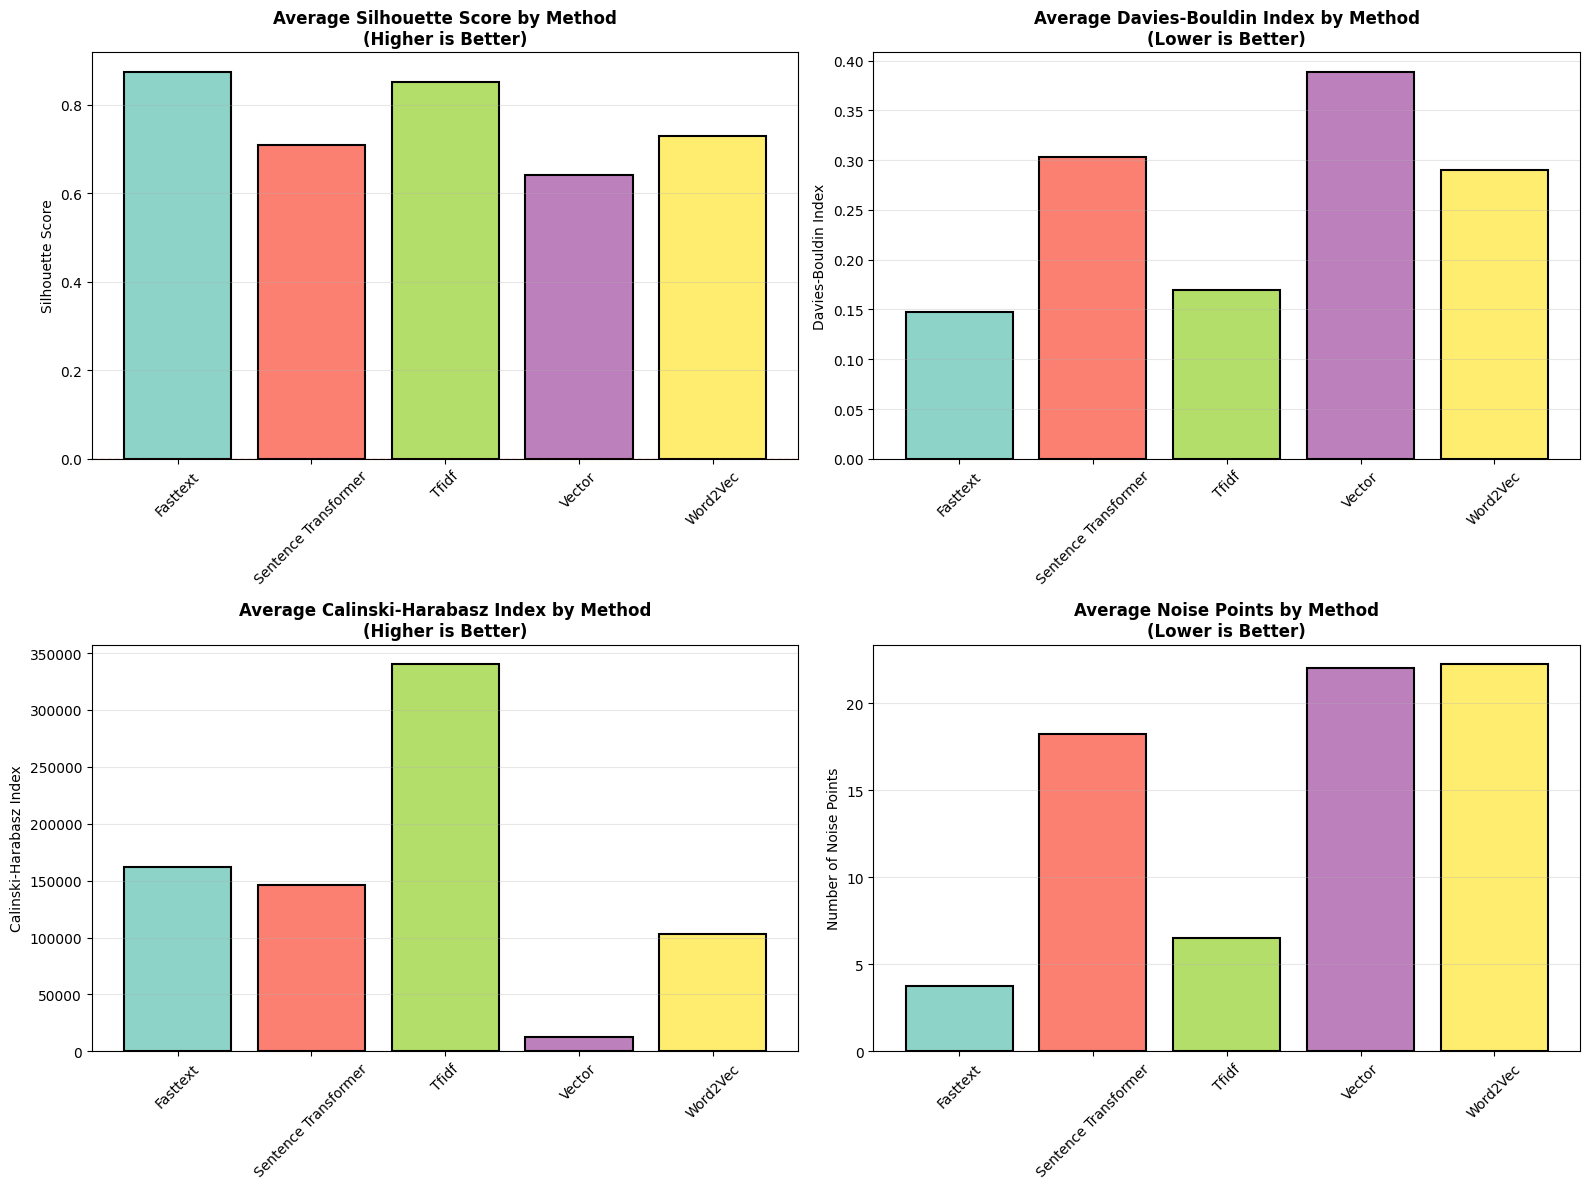

✓ Saved method comparison charts


In [27]:
# Create comparison bar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

methods = avg_metrics.index
colors = plt.cm.Set3(np.linspace(0, 1, len(methods)))

# Silhouette Score (higher is better)
axes[0, 0].bar(methods, avg_metrics['Silhouette'], color=colors, edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Average Silhouette Score by Method\n(Higher is Better)', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Davies-Bouldin Index (lower is better)
axes[0, 1].bar(methods, avg_metrics['Davies-Bouldin'], color=colors, edgecolor='black', linewidth=1.5)
axes[0, 1].set_title('Average Davies-Bouldin Index by Method\n(Lower is Better)', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Davies-Bouldin Index')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Calinski-Harabasz Index (higher is better)
axes[1, 0].bar(methods, avg_metrics['Calinski-Harabasz'], color=colors, edgecolor='black', linewidth=1.5)
axes[1, 0].set_title('Average Calinski-Harabasz Index by Method\n(Higher is Better)', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Calinski-Harabasz Index')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Noise Points (lower is better)
axes[1, 1].bar(methods, avg_metrics['Noise Points'], color=colors, edgecolor='black', linewidth=1.5)
axes[1, 1].set_title('Average Noise Points by Method\n(Lower is Better)', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Number of Noise Points')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "method_comparison_charts.png"), dpi=150)
plt.show()

print("✓ Saved method comparison charts")

## Summary

This notebook performs comprehensive workload clustering analysis comparing multiple approaches:

### Feature Extraction Methods:
1. **Vector-based**: Structural SQL features (joins, aggregates, predicates, complexity)

### Embedding Methods Compared:
2. **FastText**: Subword-aware embeddings, handles rare/OOV tokens well
3. **Word2Vec**: Classic context-based word embeddings
4. **TF-IDF**: Statistical importance weighting, interpretable features
5. **Sentence Transformers**: Pre-trained BERT-based contextual embeddings

### Pipeline:
- **Dimensionality Reduction**: UMAP (non-linear) and PCA (linear)
- **Clustering**: HDBSCAN with hyperparameter grid search
- **Evaluation**: Silhouette, Davies-Bouldin, Calinski-Harabasz, Inertia metrics
- **Output**: Visualizations, metrics CSV, representative workload selection

### Key Findings:
- Compare methods to identify which embedding type best captures SQL workload similarity
- Vector-based features provide interpretable structural information
- Different embedding methods may excel for different benchmark types
- Sentence Transformers leverage pre-trained knowledge but are computationally expensive
- FastText/Word2Vec are lightweight and fast for large workload collections

## 10. Save and Display Results

In [28]:
# Save metrics to CSV
df_metrics = pd.DataFrame(summary_results)
df_metrics.to_csv(os.path.join(output_dir, "clustering_metrics_final.csv"), index=False)

print("\n" + "="*60)
print("CLUSTERING ANALYSIS COMPLETE")
print("="*60)
print(f"\nResults saved to: {output_dir}")
print(f"Metrics saved to: clustering_metrics_final.csv\n")

# Display results
print("\nClustering Metrics Summary:")
print(df_metrics.to_string(index=False))


CLUSTERING ANALYSIS COMPLETE

Results saved to: /Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering_output
Metrics saved to: clustering_metrics_final.csv


Clustering Metrics Summary:
Benchmark               Method  Silhouette  Davies-Bouldin  Calinski-Harabasz     Inertia  Noise Points
    tpcds               Vector    0.617927        0.414338        6457.879438    2.455027            16
    tpcds             Fasttext    0.906889        0.130477        9603.512714  295.562836             0
    tpcds             Word2Vec    0.935038        0.095619       21506.170225  207.606323             0
    tpcds                Tfidf    0.869490        0.181724        5213.355339  250.388916             0
    tpcds Sentence Transformer    0.591547        0.423868        1317.760617    3.601008            19
      ssb               Vector    0.645353        0.378582       34106.968853    1.506570            43
      ssb             Fasttext    0.966856        0.046913     

## Summary

This notebook performs comprehensive workload clustering analysis comparing:
- **Vector-based features**: Structural SQL features aggregated across workloads
- **Word embeddings**: FastText embeddings of SQL tokens

Key outputs:
1. Clustering visualizations (UMAP and PCA) for each benchmark
2. Evaluation metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz, Inertia)
3. Representative workload selection based on cluster centroids
4. Comprehensive metrics CSV for further analysis